In [3]:
import pandas as pd              # Data handling
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced visualizations

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model persistence
import joblib

# Optional: Deployment
# import streamlit as st   # Uncomment if you plan to build a web app


In [4]:
df = pd.read_csv("Heart_Disease_Prediction.csv")

In [5]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [6]:
df['Heart Disease'].unique()

array(['Presence', 'Absence'], dtype=object)

In [7]:
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])

In [8]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


Text(0.5, 1.0, 'Age vs Heart Disease')

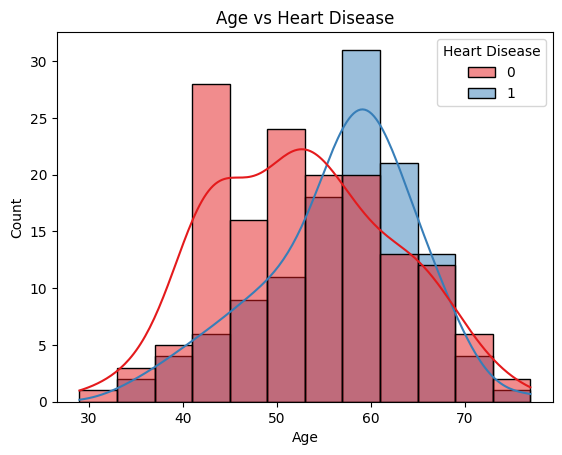

In [9]:
# Age distribution by heart disease
sns.histplot(data=df, x='Age', hue='Heart Disease', kde=True, palette='Set1')
plt.title("Age vs Heart Disease")

/tmp/ipykernel_244/2436780139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Heart Disease', data=df, palette='Set2')


Text(0.5, 1.0, 'Heart Disease Distribution (0=Absence, 1=Presence)')

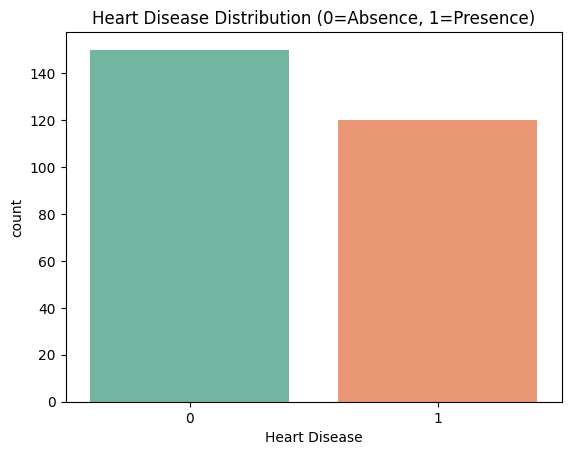

In [10]:
# Distribution of target variable
sns.countplot(x='Heart Disease', data=df, palette='Set2')
plt.title("Heart Disease Distribution (0=Absence, 1=Presence)")

Text(0.5, 1.0, 'Feature Correlation Heatmap')

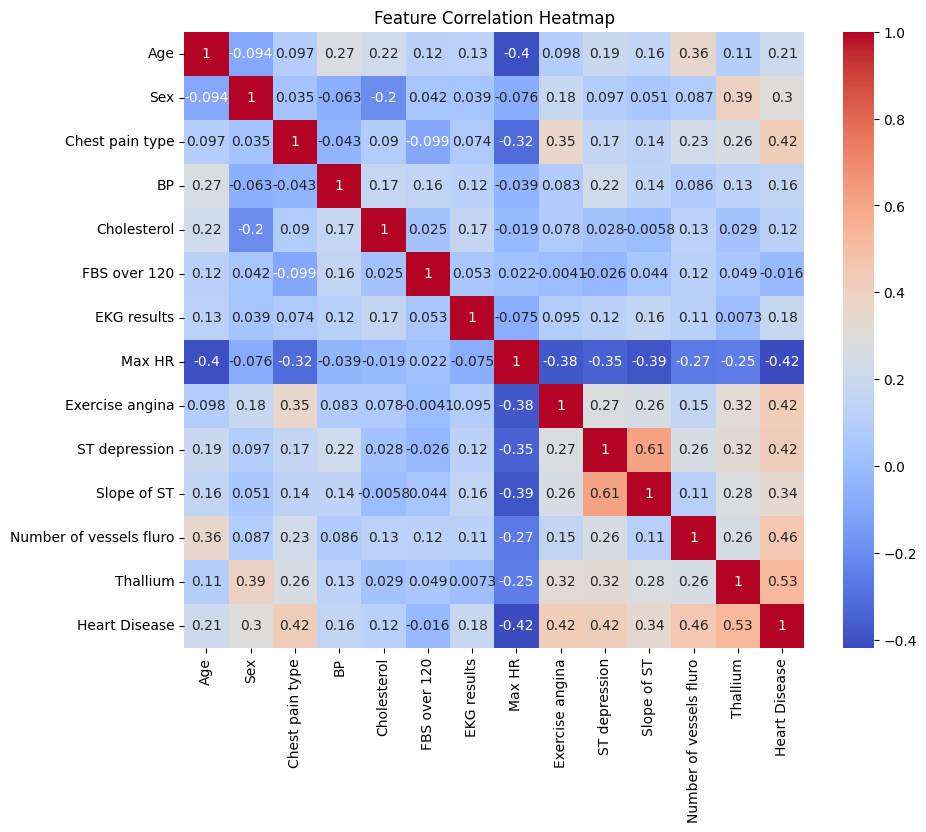

In [11]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

/tmp/ipykernel_244/2411680840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Heart Disease', y='Cholesterol', data=df, palette='Set3')


Text(0.5, 1.0, 'Cholesterol Levels by Heart Disease')

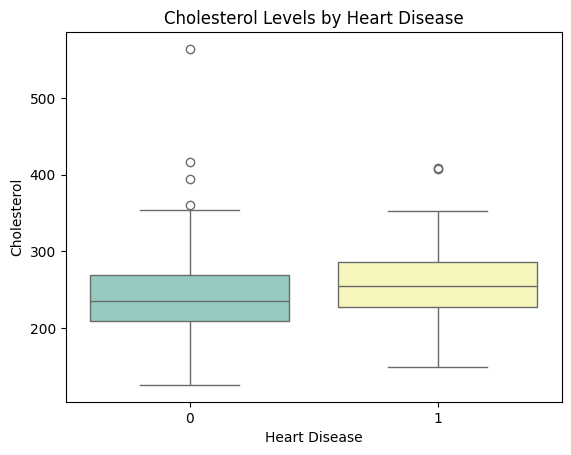

In [12]:
# Cholesterol vs Heart Disease
sns.boxplot(x='Heart Disease', y='Cholesterol', data=df, palette='Set3')
plt.title("Cholesterol Levels by Heart Disease")

In [13]:
X = df.drop("Heart Disease", axis=1)
y = df['Heart Disease']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [16]:

model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

In [17]:
model_rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [18]:
y_pred = model_rf.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)

In [20]:
accuracy

0.8222222222222222

In [22]:
joblib.dump(model_rf, "heart_disease_model.pkl")
joblib.dump(X_train.columns.tolist(), "heart_disease_columns.pkl")

['heart_disease_columns.pkl']

In [23]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']